<a href="https://colab.research.google.com/github/europecodingschool/ECS---VB---YZ---08.26/blob/main/VB_YZ_Ders_13_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

In [50]:
veri = pd.read_csv("/content/uretim_hatti_ariza.csv")

In [51]:
veri.head()

,kayit_no,uretim_hatti,vardiya,calisma_saati,son_bakim_gun,sicaklik_c,titresim,parti_no,ariza_cikti
0,5001,C,Gündüz,7570,121,66,1.7,96,Hayır
1,5002,B,Gece,2130,27,60,NaN,0,Hayır
2,5003,C,Gece,20000,45,72,2.4,97,Evet
3,5004,B,Gece,14110,43,73,0.9,35,Evet
4,5005,A,Gece,4150,118,56,6.8,12,Hayır


In [52]:
veri.shape

(604, 9)

In [53]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   kayit_no       604 non-null    int64  
 1   uretim_hatti   604 non-null    object 
 2   vardiya        604 non-null    object 
 3   calisma_saati  604 non-null    int64  
 4   son_bakim_gun  604 non-null    int64  
 5   sicaklik_c     604 non-null    int64  
 6   titresim       589 non-null    float64
 7   parti_no       604 non-null    int64  
 8   ariza_cikti    604 non-null    object 
dtypes: float64(1), int64(5), object(3)
memory usage: 42.6+ KB


In [54]:
veri.isnull().sum() #boş değerler olduğu tespit edildi. Sonrasında dolduracağız.

,0
kayit_no,0
uretim_hatti,0
vardiya,0
calisma_saati,0
son_bakim_gun,0
sicaklik_c,0
titresim,15
parti_no,0
ariza_cikti,0


In [55]:
print("Tekrar Eden Satır Sayısı:",veri.duplicated().sum())

Tekrar Eden Satır Sayısı: 4


In [56]:
print(veri[veri.duplicated(keep=False)])

     kayit_no uretim_hatti vardiya  calisma_saati  son_bakim_gun  sicaklik_c  \
25       5026            A  Gündüz           5370            130          61   
26       5026            A  Gündüz           5370            130          61   
181      5181            C  Gündüz           7350             35          71   
182      5181            C  Gündüz           7350             35          71   
312      5311            B    Gece           5140             52          69   
313      5311            B    Gece           5140             52          69   
458      5456            A    Gece           2580             27          55   
459      5456            A    Gece           2580             27          55   

     titresim  parti_no ariza_cikti  
25        3.4         7       Hayır  
26        3.4         7       Hayır  
181       0.6         3        Evet  
182       0.6         3        Evet  
312       1.8         0       Hayır  
313       1.8         0       Hayır  
458       1.6

In [57]:
veri.describe()

,kayit_no,calisma_saati,son_bakim_gun,sicaklik_c,titresim,parti_no
count,604.000000,604.000000,604.000000,604.000000,589.000000,604.000000
mean,5300.122517,7350.761589,101.490066,65.470199,3.263158,49.761589
std,173.318909,4880.095432,97.746287,6.465428,2.033140,29.608548
min,5001.000000,200.000000,1.000000,50.000000,0.300000,0.000000
25%,5150.750000,3557.500000,28.000000,61.000000,1.700000,23.000000
50%,5300.500000,7050.000000,68.500000,65.000000,2.900000,51.000000
75%,5450.250000,10582.500000,142.500000,70.000000,4.300000,76.000000
max,5600.000000,20000.000000,400.000000,86.000000,9.500000,99.000000


In [58]:
#VERİYİ TEMİZLEME
veri = veri.drop_duplicates() # tekrarlayan 4 satırı sildik ve verinin şeklini tekrar kontrol ettik.
veri.shape

(600, 9)

In [59]:
# Veride bulunan boşlukları dolduralım.
ortanca_titresim = veri["titresim"].median()
ortanca_titresim

2.9

In [60]:
veri["titresim"] = veri["titresim"].fillna(ortanca_titresim) # verimizin boşluklarını sütunun medianı ile doldurduk. Ortalama ile de doldurabilirdik.
veri.isnull().sum()

,0
kayit_no,0
uretim_hatti,0
vardiya,0
calisma_saati,0
son_bakim_gun,0
sicaklik_c,0
titresim,0
parti_no,0
ariza_cikti,0


In [61]:
sayilar = veri["ariza_cikti"].value_counts()
sayilar

,count
ariza_cikti,
Hayır,344
Evet,256


In [62]:
sayilar_oran = veri["ariza_cikti"].value_counts(normalize=True)
sayilar_oran

,proportion
ariza_cikti,
Hayır,0.573333
Evet,0.426667


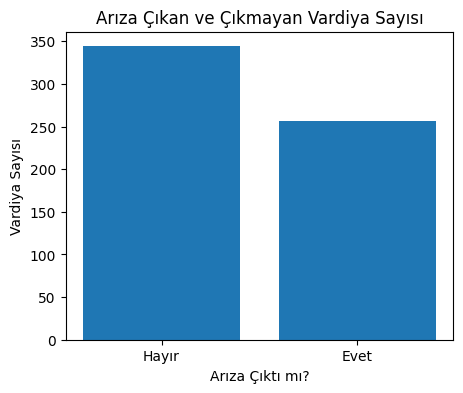

In [63]:
plt.figure(figsize=(5,4))
plt.bar(sayilar.index, sayilar.values)
plt.title("Arıza Çıkan ve Çıkmayan Vardiya Sayısı")
plt.xlabel("Arıza Çıktı mı?")
plt.ylabel("Vardiya Sayısı")
plt.show()

In [64]:
evet = veri[veri["ariza_cikti"] == "Evet"]
hayır = veri[veri['ariza_cikti'] == "Hayır"]
print(len(evet))
print(len(hayır))

256
344


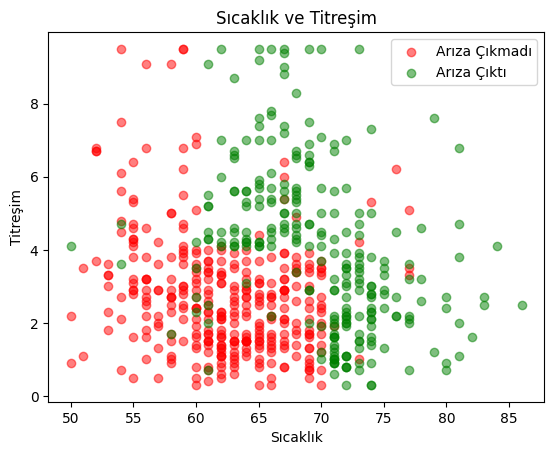

In [65]:
plt.scatter(hayır["sicaklik_c"], hayır["titresim"], color="r", alpha=0.5, label="Arıza Çıkmadı")
plt.scatter(evet["sicaklik_c"], evet["titresim"], color="g", alpha=0.5, label="Arıza Çıktı")
plt.title("Sıcaklık ve Titreşim")
plt.xlabel("Sıcaklık")
plt.ylabel("Titreşim")
plt.legend()
plt.show()

In [66]:
veri = pd.get_dummies(veri, columns=["uretim_hatti", "vardiya"], drop_first=True, dtype=int)
veri.head()

,kayit_no,calisma_saati,son_bakim_gun,sicaklik_c,titresim,parti_no,ariza_cikti,uretim_hatti_B,uretim_hatti_C,vardiya_Gündüz
0,5001,7570,121,66,1.7,96,Hayır,0,1,1
1,5002,2130,27,60,2.9,0,Hayır,1,0,0
2,5003,20000,45,72,2.4,97,Evet,0,1,0
3,5004,14110,43,73,0.9,35,Evet,1,0,0
4,5005,4150,118,56,6.8,12,Hayır,0,0,0


In [68]:
# X ve y olarak ayırma

X = veri[["calisma_saati","son_bakim_gun","sicaklik_c","titresim","parti_no","uretim_hatti_B","uretim_hatti_C","vardiya_Gündüz"]]
y = veri["ariza_cikti"]

In [70]:
X.head()

,calisma_saati,son_bakim_gun,sicaklik_c,titresim,parti_no,uretim_hatti_B,uretim_hatti_C,vardiya_Gündüz
0,7570,121,66,1.7,96,0,1,1
1,2130,27,60,2.9,0,1,0,0
2,20000,45,72,2.4,97,0,1,0
3,14110,43,73,0.9,35,1,0,0
4,4150,118,56,6.8,12,0,0,0


In [73]:
#Eğitim ve Test olarak ayırma

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Eğitim:", X_train.shape)
print("Test:", X_test.shape)

Eğitim: (480, 8)
Test: (120, 8)


In [75]:
agac_sinirsiz = DecisionTreeClassifier(random_state=42)
agac_sinirsiz.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [78]:
accuracy_score(y_test, agac_sinirsiz.predict(X_test))

0.875

In [80]:
print("Ağaç Derinliği:", agac_sinirsiz.get_depth())
print("Yaprak Sayısı:", agac_sinirsiz.get_n_leaves())

Ağaç Derinliği: 11
Yaprak Sayısı: 47


In [82]:
# Karar Ağacımıza budama yapıyoruz. Sınır koyuyoruz.
agac3 = DecisionTreeClassifier(max_depth=3, random_state=42)
agac3.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [84]:
accuracy_score(y_test, agac3.predict(X_test))

0.9166666666666666

In [86]:
print("Yaprak Sayısı:", agac3.get_n_leaves())

Yaprak Sayısı: 8


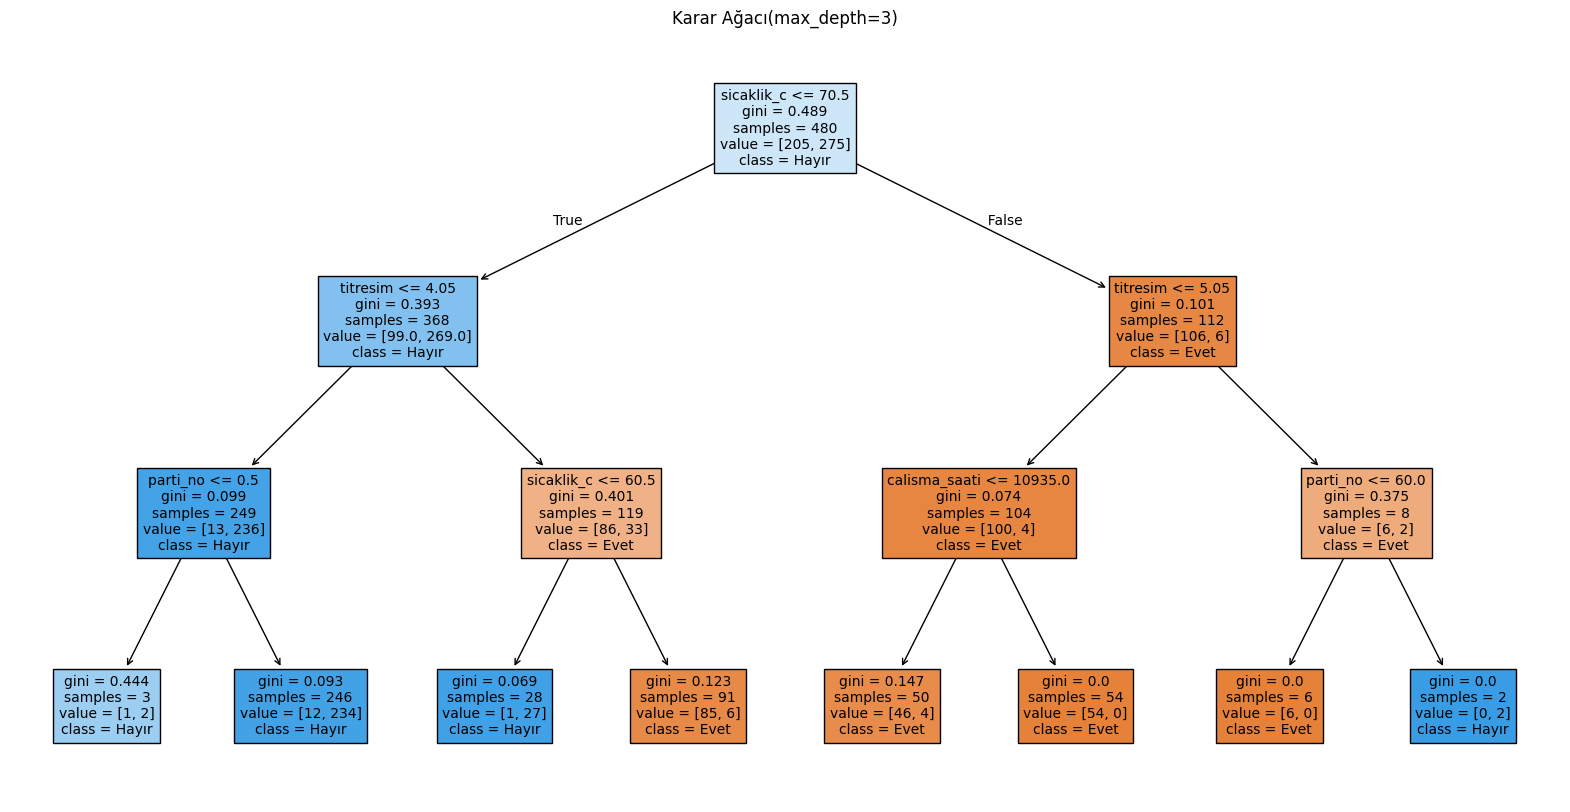

In [88]:
plt.figure(figsize=(20,10))
plot_tree(agac3, feature_names=list(X.columns), class_names=["Evet", "Hayır"], filled=True)
plt.title("Karar Ağacı(max_depth=3)")
plt.show()
#

Karar Ağacı ilk soru olarak sicaklık_c sütununu seçmiş. bu düğüm ile başlıyor.
samples: Bu kutuya düşen eğitim kaydı sayısı.
value: sınıfların sayısı. önce evet sonra hayır.
gini: kutunun ne kadar karışık olduğu. (saflık) 0 = tek sınıf var. 0,5 ise yarı yarıya

In [90]:
agac = DecisionTreeClassifier(max_depth=3, random_state=42, min_impurity_decrease=0.005)
agac.fit(X_train, y_train)
tahmin= agac.predict(X_test)

In [92]:
accuracy_score(y_test, tahmin)

0.925

In [95]:
print("Yaprak Sayısı:", agac.get_n_leaves()) # Faydasız soruları sormayı kes.

Yaprak Sayısı: 4


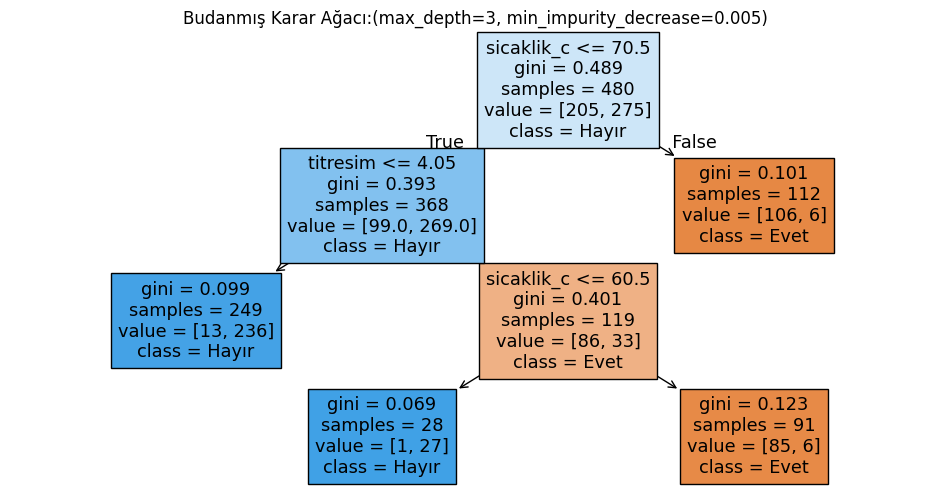

In [97]:
plt.figure(figsize=(12,6))
plot_tree(agac, feature_names=list(X.columns), class_names=["Evet", "Hayır"], filled=True)
plt.title("Budanmış Karar Ağacı:(max_depth=3, min_impurity_decrease=0.005)")
plt.show()